# Zadanie domowe

W przypadku obrazów w odcieniach szarości pojedynczy piksel z zakresu [0; 255] reprezentowany jest jako 8-bitowa liczba bez znaku.
Pewnym rozszerzeniem analizy sposobu reprezentacji obrazu może być następujący eksperyment.
Załóżmy, że z każdego z 8 bitów możemy stworzyć pojedynczy obraz binarny (ang. _bit-plane slicing_).
Dla obrazka _100zloty.jpg_ (https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/100zloty.jpg) stwórz 8 obrazów, z których każdy powinien zawierać jedną płaszczyznę bitową.
Podpowiedź $-$ warto sprawdzić, jak realizuje się bitowe operacje logiczne.
Zastosowanie takiej dekompozycji obrazu pozwala na analizę ,,ważności'' poszczególnych bitów.
Jest to użyteczne w kwantyzacji, ale także w kompresji.

W drugim etapie zadania proszę spróbować odtworzyć obraz oryginalny z mniejszej liczby obrazów binarnych.
Warto zacząć od dwóch najbardziej znaczących bitów, a później dodawać kolejne.
Należy utworzyć co najmniej trzy wersje zrekonstruowanych obrazów.
Podpowiedź $-$ rekonstrukcja obrazu to mnożenie przez odpowiednią potęgę liczby 2 (przesunięcie bitowe) oraz dodawanie.

In [ ]:
import cv2
import os
import requests
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/'
file_name = '100zloty.jpg'
if not os.path.exists(file_name) :
    r = requests.get(url + file_name, allow_redirects=True)
    open(file_name, 'wb').write(r.content)

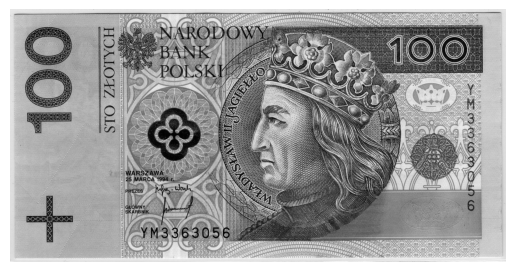

In [ ]:
img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)
plt.axis('off')
plt.imshow(img, cmap='gray')

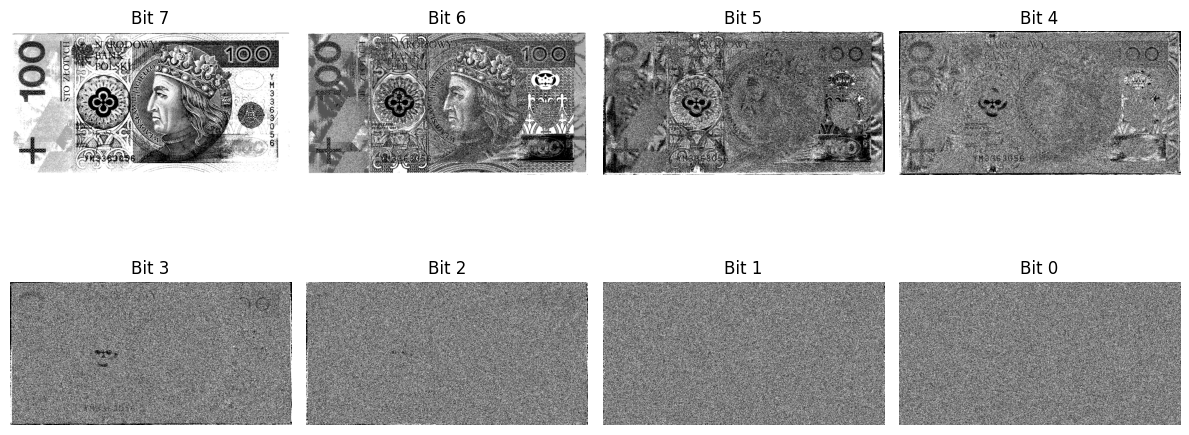

In [ ]:
img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

bit_planes = [(img >> i) & 1 for i in range(8)]

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(bit_planes[7 - i] * 255, cmap='gray')
    plt.title(f'Bit {7 - i}')
    plt.axis('off')
plt.tight_layout()
plt.show()

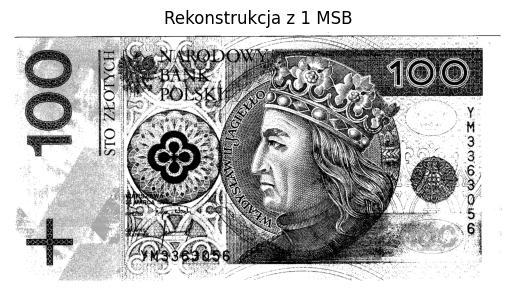

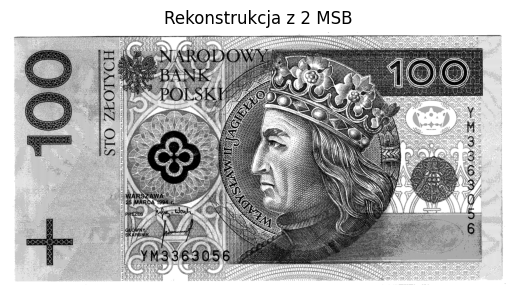

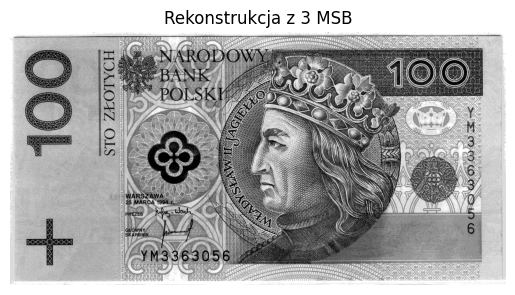

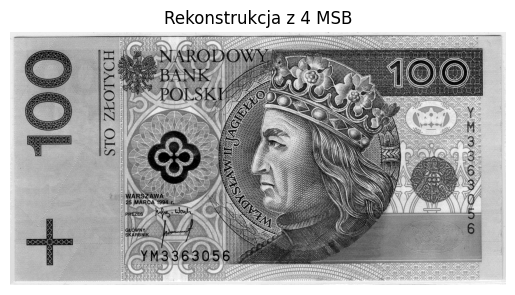

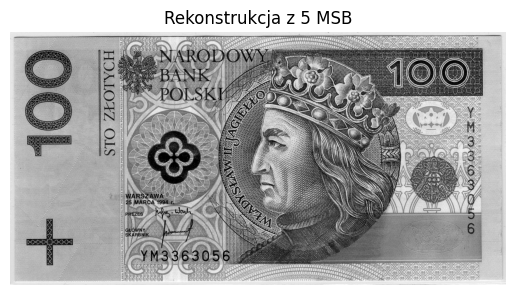

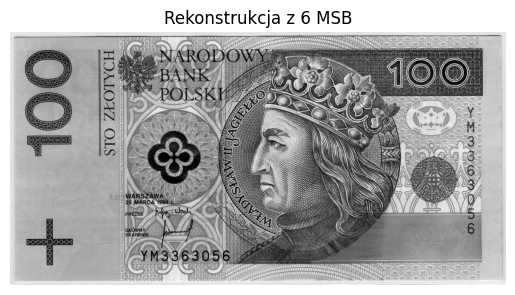

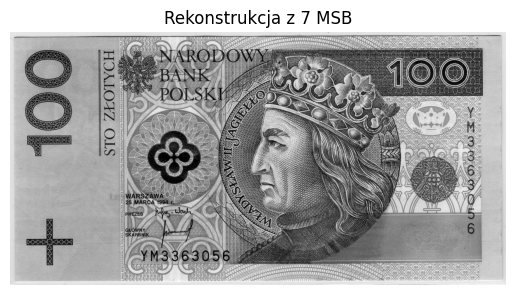

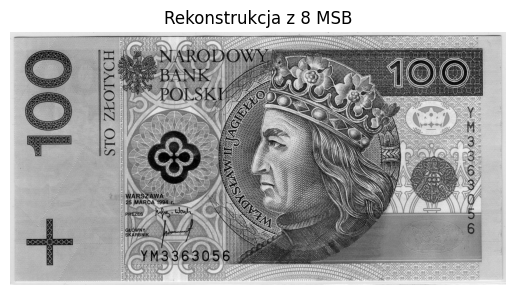

In [ ]:
def MSB(n):
    # Rekonstrukcja z n najbardziej znaczących bitów
    recon = sum([bit_planes[7 - j] * (2 ** (7 - j)) for j in range(n)])

    plt.imshow(recon, cmap='gray')
    plt.title(f"Rekonstrukcja z {n} MSB")
    plt.axis('off')
    plt.show()

# Wyświetlenie rekonstrukcji od 1 do 8 bitów
for n in range(1, 9):
    MSB(n)